# Chaining `TrueMeasure` Transformations with Compatible Domains

This notebook demonstrates a generalization of the compatibility rule used when chaining `TrueMeasure` transformations in QMCPy.

Previously, consecutive transformations were considered compatible only when the range of the preceding transformation exactly matched the domain of the next transformation.

This notebook shows why exact equality is unnecessarily restrictive and demonstrates the proposed range-in-domain condition for one-dimensional intervals and multidimensional axis-aligned boxes.

## Motivation

A chained transformation passes the output of one transformation into the next.

Consider two consecutive transformations

$$
T_{j-1}: D_{j-1} \rightarrow R_{j-1}
$$

and

$$
T_j: D_j \rightarrow R_j.
$$

The output of $T_{j-1}$ becomes the input to $T_j$.

Therefore, the important compatibility question is:

> Can every value produced by $T_{j-1}$ be accepted by $T_j$?

Previously, QMCPy effectively required

$$
R_{j-1} = D_j.
$$

However, exact equality is stronger than necessary.

For the domain/range compatibility of two consecutive transformations, exact equality is not required. It is sufficient that every value produced by the preceding transformation lies inside the domain accepted by the next transformation:

$$
R_{j-1} \subseteq D_j.
$$

This condition addresses whether the two transformations are compatible at their shared boundary. Other requirements of the individual transformations remain unchanged.

### Simple example

Suppose the previous transformation produces values only in

$$
R_{j-1} = [0.25, 0.75],
$$

while the next transformation accepts every value in

$$
D_j = [0,1].
$$

The two sets are not equal:

$$
[0.25,0.75] \neq [0,1].
$$

However,

$$
[0.25,0.75] \subseteq [0,1].
$$

Every output of the previous transformation therefore lies within the input domain accepted by the next transformation.

Rejecting this composition only because the two intervals are not identical is unnecessarily restrictive.

## Compatibility rule

For a one-dimensional range

$$
R = [r_L,r_U]
$$

and domain

$$
D = [d_L,d_U],
$$

the range is contained within the domain when

$$
d_L \leq r_L
$$

and

$$
r_U \leq d_U.
$$

Both conditions must hold.

For example,

$$
[1,3] \subseteq [0,4]
$$

because

$$
0 \leq 1
$$

and

$$
3 \leq 4.
$$

### Multidimensional case

QMCPy also works with multidimensional domains and ranges.

For an axis-aligned box,

$$
R =
[r_1^L,r_1^U]
\times
\cdots
\times
[r_d^L,r_d^U]
$$

and

$$
D =
[d_1^L,d_1^U]
\times
\cdots
\times
[d_d^L,d_d^U].
$$

Compatibility is checked independently in every coordinate.

For every dimension $i$,

$$
d_i^L \leq r_i^L
$$

and

$$
r_i^U \leq d_i^U.
$$

If even one coordinate violates the condition, the chained transformation is incompatible.

### Scope of this change

The initial compatibility rule is intentionally limited to support metadata represented by:

- one-dimensional intervals;
- multidimensional axis-aligned boxes;
- finite or unbounded numerical endpoints.

For example,

$$
[1,3]\times[2,5]\times(-\infty,\infty)
$$

can be checked coordinate by coordinate.

This change does **not** attempt to represent disconnected supports such as

$$
[0,5]\cup[10,20],
$$

or arbitrary nonrectangular regions.

Those cases would require a richer representation of a measure's support and are outside the scope of this change.

### Visualizing the multidimensional rule

In two dimensions, compatibility means that the entire inner rectangle must lie inside the outer domain rectangle.

The check is still performed coordinate by coordinate.

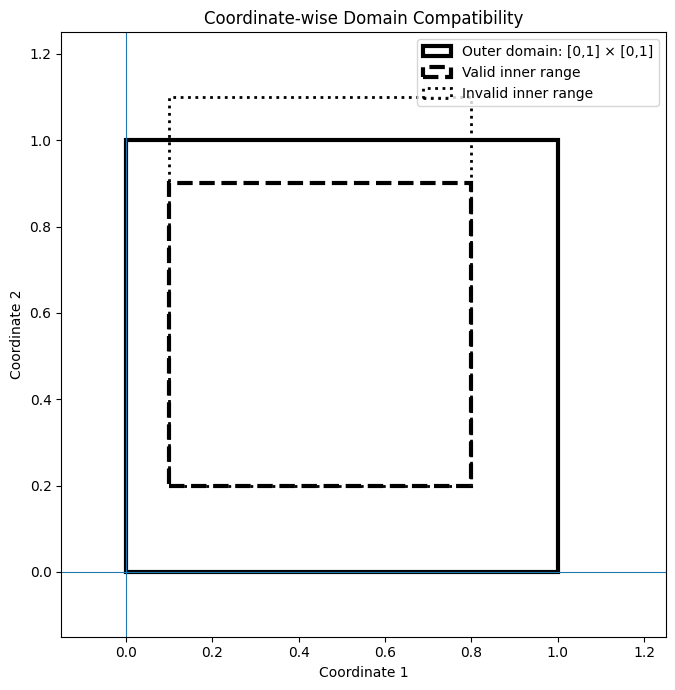

In [613]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(7, 7))

# Outer domain: [0,1] x [0,1]
outer_domain = Rectangle(
    (0, 0),
    1,
    1,
    fill=False,
    linewidth=3,
    label="Outer domain: [0,1] × [0,1]",
)

# Valid range: [0.1,0.8] x [0.2,0.9]
valid_range = Rectangle(
    (0.1, 0.2),
    0.7,
    0.7,
    fill=False,
    linewidth=3,
    linestyle="--",
    label="Valid inner range",
)

# Invalid range: [0.1,0.8] x [0.2,1.1]
invalid_range = Rectangle(
    (0.1, 0.2),
    0.7,
    0.9,
    fill=False,
    linewidth=2,
    linestyle=":",
    label="Invalid inner range",
)

ax.add_patch(outer_domain)
ax.add_patch(valid_range)
ax.add_patch(invalid_range)

ax.set_xlim(-0.15, 1.25)
ax.set_ylim(-0.15, 1.25)

ax.set_xlabel("Coordinate 1")
ax.set_ylabel("Coordinate 2")
ax.set_title("Coordinate-wise Domain Compatibility")

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.legend()
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

The dashed rectangle is compatible because both coordinate intervals are contained within the unit-domain intervals:

$$
[0.1,0.8]\subseteq[0,1]
$$

and

$$
[0.2,0.9]\subseteq[0,1].
$$

The dotted rectangle is incompatible because its second coordinate extends to $1.1$:

$$
[0.2,1.1]\nsubseteq[0,1].
$$

This illustrates why multidimensional compatibility can be checked independently along each coordinate for axis-aligned boxes.

### Unbounded intervals and endpoint representation

Some QMCPy measures have unbounded domains or ranges, such as

$$
(-\infty,\infty)
$$

or

$$
[0,\infty).
$$

Infinity is not an element of these sets. In the implementation, `-np.inf` and `np.inf` are numerical representations of unbounded lower and upper endpoints.

The current `TrueMeasure` metadata records lower and upper bounds, but it does not separately record whether a finite endpoint is open or closed.

Because the current metadata stores only numerical lower and upper bounds, the implemented compatibility test is most precisely understood as comparing the stored interval envelopes. When discussing endpoint behavior mathematically, this is closely related to comparing closures of the represented supports:

$$
\overline{R}_{j-1} \subseteq \overline{D}_j.
$$

For example,

$$
\overline{(0,1)}=[0,1].
$$

At the numerical level, the same coordinate-wise comparisons are used:

$$
d_L \leq r_L
\qquad\text{and}\qquad
r_U \leq d_U.
$$

For example, a stored range with bounds $[-5,5]$ is compatible with an unbounded real-valued domain because

$$
-\infty \leq -5
\qquad\text{and}\qquad
5 \leq \infty.
$$

This initial change does not attempt to distinguish cases such as $(0,1)$ and $[0,1]$ when their stored numerical bounds are identical. Explicit open/closed endpoint metadata would require a richer support representation and can be considered separately.

In [614]:
import numpy as np
import pandas as pd

from qmcpy import DigitalNetB2, Kumaraswamy, Uniform
from qmcpy.true_measure.abstract_true_measure import AbstractTrueMeasure
from qmcpy.util import ParameterError

## Previous behavior: exact equality

Previously, chained `TrueMeasure` compatibility was determined using an exact comparison between the next transformation's domain and the preceding transformation's range.

Conceptually, the check was equivalent to:

In [615]:
def previous_compatibility_check(transform_range, domain):
    """Reproduce the previous exact-equality compatibility rule."""
    return not (np.asarray(domain) != np.asarray(transform_range)).any()

In [616]:
transform_range = np.array([[0.25, 0.75]])
domain = np.array([[0.0, 1.0]])

previous_compatibility_check(transform_range, domain)

False

The previous rule rejects this pair because

$$
[0.25,0.75] \neq [0,1].
$$

But this does not mean the transformation is invalid. Every value in the preceding range is still inside the next domain.

In [617]:
AbstractTrueMeasure._range_in_domain(
    transform_range,
    domain,
)

True

The new compatibility rule accepts the same pair because

$$
[0.25,0.75] \subseteq [0,1].
$$

This captures the actual requirement for composition: every value produced by the previous transformation can be passed safely to the next transformation.

## What changed in QMCPy?

The previous `TrueMeasure` composition logic required the domain of the current transformation to exactly match the range of the preceding transformation.

The previous compatibility check was:

```python
if (self.domain != self.transform.range).any():
    self.sub_compatibility_error = True
```

For two consecutive transformations,

$$
T_{j-1}: D_{j-1} \rightarrow R_{j-1}
$$

and

$$
T_j: D_j \rightarrow R_j,
$$

this effectively required

$$
R_{j-1} = D_j.
$$

This rejects cases where the preceding range is smaller than, but still completely contained within, the next domain.

For example,

$$
R_{j-1}=[0.25,0.75]
$$

and

$$
D_j=[0,1]
$$

were considered incompatible because

$$
[0.25,0.75] \neq [0,1].
$$

However, every value produced by the preceding transformation is a valid input to the next transformation because

$$
[0.25,0.75] \subseteq [0,1].
$$

### Updated compatibility check

The implementation now checks whether the preceding transformation's range is contained within the current transformation's domain:

```python
if not self._range_in_domain(self.transform.range, self.domain):
    self.sub_compatibility_error = True
```

For one coordinate, let

$$
R_{j-1}=[r_L,r_U]
$$

and

$$
D_j=[d_L,d_U].
$$

The range is compatible with the next domain when

$$
d_L \leq r_L
$$

and

$$
r_U \leq d_U.
$$

For multiple dimensions, the same comparison is performed independently for every coordinate $i$:

$$
d_i^L \leq r_i^L
\qquad\text{and}\qquad
r_i^U \leq d_i^U.
$$

Therefore, the compatibility rule changes from

$$
\boxed{R_{j-1}=D_j}
$$

to

$$
\boxed{R_{j-1}\subseteq D_j}.
$$

Exact equality is still accepted because it is a special case of containment.

The implementation also preserves QMCPy's existing broadcasting behavior between a common `(1, 2)` domain and a coordinate-specific `(d, 2)` range.

For example, a common domain

```text
[[0, 1]]
```

can be compared against a two-dimensional range

```text
[[0.1, 0.8],
 [0.2, 0.9]]
```

because both coordinate intervals satisfy

$$
[0.1,0.8]\subseteq[0,1]
$$

and

$$
[0.2,0.9]\subseteq[0,1].
$$

This change only generalizes **domain-range compatibility**. It does not change the individual transformations themselves, the direct unit-cube requirement for a `StdUniform` discrete distribution, or the separate importance-sampling compatibility logic.

In [618]:
examples = [
    ("Exact equality", [[0, 1]], [[0, 1]]),
    ("Strict inclusion", [[0.25, 0.75]], [[0, 1]]),
    ("Infinite domain", [[-5, 5]], [[-np.inf, np.inf]]),
    ("Positive half-line", [[1, 3]], [[0, np.inf]]),
    ("Lower-bound failure", [[-0.1, 0.75]], [[0, 1]]),
    ("Upper-bound failure", [[0.25, 1.1]], [[0, 1]]),
]

rows = []

for name, transform_range, domain in examples:
    rows.append(
        {
            "Case": name,
            "Previous equality rule": previous_compatibility_check(
                transform_range,
                domain,
            ),
            "New inclusion rule": AbstractTrueMeasure._range_in_domain(
                transform_range,
                domain,
            ),
        }
    )

pd.DataFrame(rows)

,Case,Previous equality rule,New inclusion rule
0,Exact equality,True,True
1,Strict inclusion,False,True
2,Infinite domain,False,True
3,Positive half-line,False,True
4,Lower-bound failure,False,False
5,Upper-bound failure,False,False


The new rule does not make incompatible transformations valid.

It only distinguishes between:

- a range that is different from, but safely contained within, the next domain; and
- a range that actually extends outside the next domain.

## A real chained `TrueMeasure` example

Consider an inner `Uniform` transformation whose output is restricted to

$$
[0.25,0.75].
$$

A `Kumaraswamy` transformation accepts inputs from

$$
[0,1].
$$

Therefore,

$$
[0.25,0.75] \subseteq [0,1].
$$

Under the previous exact-equality rule, this chain was marked incompatible.

Under the new containment rule, the two transformations are domain-compatible and the chain can be evaluated successfully.

In [619]:
inner = Uniform(
    DigitalNetB2(1, seed=7),
    lower_bound=0.25,
    upper_bound=0.75,
)

outer = Kumaraswamy(inner)

print("Inner range:")
print(inner.range)

print("\nOuter domain:")
print(outer.domain)

print(
    "\nRange contained in domain:",
    AbstractTrueMeasure._range_in_domain(
        inner.range,
        outer.domain,
    ),
)

print("\nCompatibility error:")
print(outer.sub_compatibility_error)

Inner range:
[[0.25 0.75]]

Outer domain:
[[0 1]]

Range contained in domain: True

Compatibility error:
False


In [620]:
samples = outer.gen_samples(8)

samples

array([[0.49764069],
       [0.6423285 ],
       [0.40482463],
       [0.55578408],
       [0.53096826],
       [0.67279285],
       [0.44112426],
       [0.58532942]])

In [621]:
print("Sample shape:", samples.shape)
print("All samples finite:", np.isfinite(samples).all())

Sample shape: (8, 1)
All samples finite: True


The chain now executes successfully because the output of the inner transformation always lies inside the domain of the outer transformation.

The important change is not that the two intervals became equal. They remain different.

The change is that QMCPy now recognizes their domain-compatible containment relationship.

## Multidimensional composition

Now consider an inner transformation with two coordinate ranges:

$$
[0.1,0.8] \times [0.2,0.9].
$$

The outer Kumaraswamy transformation accepts the unit interval in each coordinate:

$$
[0,1] \times [0,1].
$$

Coordinate 1 satisfies

$$
[0.1,0.8] \subseteq [0,1],
$$

and coordinate 2 satisfies

$$
[0.2,0.9] \subseteq [0,1].
$$

Therefore the entire box is compatible.

In [622]:
inner_2d = Uniform(
    DigitalNetB2(2, seed=7),
    lower_bound=[0.1, 0.2],
    upper_bound=[0.8, 0.9],
)

outer_2d = Kumaraswamy(inner_2d)

print("Inner range:")
print(inner_2d.range)

print("\nOuter domain:")
print(outer_2d.domain)

print(
    "\nRange contained in domain:",
    AbstractTrueMeasure._range_in_domain(
        inner_2d.range,
        outer_2d.domain,
    ),
)

print("\nCompatibility error:")
print(outer_2d.sub_compatibility_error)

Inner range:
[[0.1 0.8]
 [0.2 0.9]]

Outer domain:
[[0 1]]

Range contained in domain: True

Compatibility error:
False


In [623]:
samples_2d = outer_2d.gen_samples(8)

print(samples_2d)
print("\nShape:", samples_2d.shape)

[[0.60960507 0.77497487]
 [0.3371496  0.54168863]
 [0.7365757  0.34514116]
 [0.47524005 0.60047814]
 [0.53970404 0.47173912]
 [0.22682022 0.69013017]
 [0.66124946 0.64063827]
 [0.39411447 0.40037581]]

Shape: (8, 2)


This example also demonstrates an important QMCPy representation detail.

The inner `Uniform` stores one interval for each coordinate, while the outer `Kumaraswamy` stores a common unit-domain interval.

The compatibility check therefore preserves NumPy broadcasting between `(d,2)` and `(1,2)` representations.

## An actually incompatible chain

Containment should not permit ranges that extend outside the next transformation's domain.

Suppose the inner range is

$$
[-0.1,0.75]
$$

while the outer domain is

$$
[0,1].
$$

Because

$$
-0.1 < 0,
$$

the range is not contained within the domain.

In [624]:
invalid_inner = Uniform(
    DigitalNetB2(1, seed=7),
    lower_bound=-0.1,
    upper_bound=0.75,
)

invalid_outer = Kumaraswamy(invalid_inner)

print(
    "Range contained in domain:",
    AbstractTrueMeasure._range_in_domain(
        invalid_inner.range,
        invalid_outer.domain,
    ),
)
print("Compatibility error:", invalid_outer.sub_compatibility_error)

Range contained in domain: False
Compatibility error: True


In [625]:
try:
    invalid_outer.gen_samples(8)
except ParameterError as error:
    print(type(error).__name__)
    print(error)

ParameterError
The sub-transform range must be contained within the transform domain.


The generalized rule does not remove compatibility checking.

It allows strict inclusion, but still rejects transformations whose preceding range contains values outside the next domain.

## Visualizing range-in-domain compatibility

The compatibility condition can also be seen geometrically.

The outer transformation accepts values in the domain $[0,1]$.

- The range $[0.25,0.75]$ lies completely inside the domain, so it is compatible.
- The range $[-0.1,0.75]$ extends outside the lower boundary of the domain, so it is incompatible.

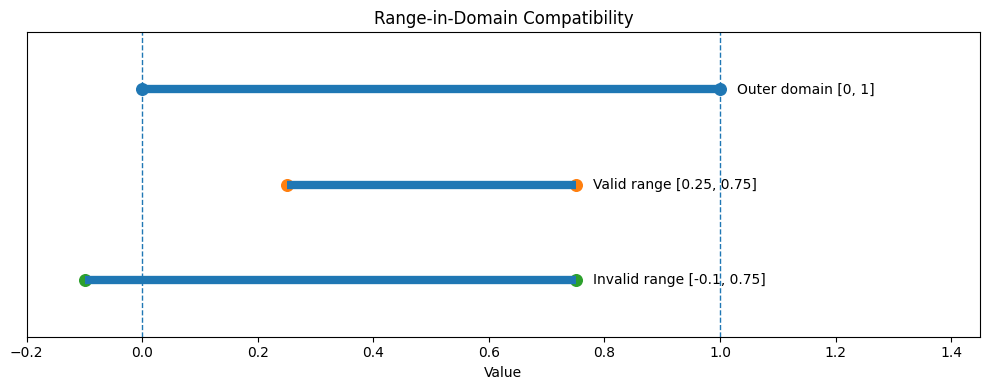

In [626]:
import matplotlib.pyplot as plt

# Outer transformation domain
domain_lower = 0.0
domain_upper = 1.0

# A valid preceding range
valid_lower = 0.25
valid_upper = 0.75

# An invalid preceding range
invalid_lower = -0.1
invalid_upper = 0.75

plt.figure(figsize=(10, 4))

# Draw the outer domain
plt.hlines(
    y=2,
    xmin=domain_lower,
    xmax=domain_upper,
    linewidth=6,
)
plt.scatter(
    [domain_lower, domain_upper],
    [2, 2],
    s=70,
)

# Draw the valid inner range
plt.hlines(
    y=1,
    xmin=valid_lower,
    xmax=valid_upper,
    linewidth=6,
)
plt.scatter(
    [valid_lower, valid_upper],
    [1, 1],
    s=70,
)

# Draw the invalid inner range
plt.hlines(
    y=0,
    xmin=invalid_lower,
    xmax=invalid_upper,
    linewidth=6,
)
plt.scatter(
    [invalid_lower, invalid_upper],
    [0, 0],
    s=70,
)

# Labels
plt.text(
    domain_upper + 0.03,
    2,
    "Outer domain [0, 1]",
    va="center",
)

plt.text(
    valid_upper + 0.03,
    1,
    "Valid range [0.25, 0.75]",
    va="center",
)

plt.text(
    invalid_upper + 0.03,
    0,
    "Invalid range [-0.1, 0.75]",
    va="center",
)

# Show the domain boundaries
plt.axvline(
    domain_lower,
    linestyle="--",
    linewidth=1,
)

plt.axvline(
    domain_upper,
    linestyle="--",
    linewidth=1,
)

plt.yticks([])
plt.xlabel("Value")
plt.title("Range-in-Domain Compatibility")

plt.xlim(-0.2, 1.45)
plt.ylim(-0.6, 2.6)

plt.tight_layout()
plt.show()

The middle interval is compatible because

$$
[0.25,0.75] \subseteq [0,1].
$$

The bottom interval is incompatible because part of its range lies outside the accepted domain:

$$
[-0.1,0.75] \nsubseteq [0,1].
$$

This illustrates why exact equality is not required. The preceding range only needs to remain completely within the next transformation's domain.

### Two different questions

For chained `TrueMeasure` compatibility,

$$
T_{j-1}
\longrightarrow
R_{j-1} \subseteq D_j
\longrightarrow
T_j.
$$

The question is whether the output of one existing transformation can legally become the input of the next. Gaussian-to-Logistic transport asks a different question: how to construct a deterministic transformation between two probability measures,

$$
X_G \xrightarrow{\Phi} U \xrightarrow{F_L^{-1}} X_L.
$$

These are related through transformation boundaries, but they are not the same operation.

# Exploring Gaussian, Uniform, and Logistic transformations

The domain-inclusion change solves compatibility between transformations whose existing maps can already be composed.

A separate question is how transformations between different probability measures should be ordered.

This distinction is important for Gaussian, Uniform, and Logistic distributions.

Let

$$
U \sim \mathrm{Uniform}(0,1).
$$

A standard Gaussian variable can be generated using the Gaussian inverse CDF:

$$
X_G = \Phi^{-1}(U).
$$

Similarly, a standard Logistic variable can be generated using

$$
X_L = F_L^{-1}(U),
$$

where $F_L$ is the Logistic CDF.

Thus both inverse-CDF transformations naturally have the form

$$
(0,1) \rightarrow \mathbb{R}.
$$

## Gaussian to Logistic

If the starting variable is Gaussian,

$$
X_G \sim N(0,1),
$$

we cannot directly apply another inverse CDF expecting a unit-uniform input.

We first map the Gaussian variable back to the unit interval using its CDF:

$$
U = \Phi(X_G).
$$

Then apply the Logistic inverse CDF:

$$
X_L = F_L^{-1}(U).
$$

Therefore,

$$
X_G
\xrightarrow{\Phi}
U
\xrightarrow{F_L^{-1}}
X_L.
$$

The mathematical transport is

$$
\mathrm{Gaussian}
\rightarrow
\mathrm{Uniform}
\rightarrow
\mathrm{Logistic}.
$$

Similarly,

$$
X_L
\xrightarrow{F_L}
U
\xrightarrow{\Phi^{-1}}
X_G
$$

gives

$$
\mathrm{Logistic}
\rightarrow
\mathrm{Uniform}
\rightarrow
\mathrm{Gaussian}.
$$

In [627]:
from scipy.stats import norm, logistic

In [628]:
x_gaussian = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])

u = norm.cdf(x_gaussian)
x_logistic = logistic.ppf(u)

pd.DataFrame(
    {
        "Gaussian x": x_gaussian,
        "Phi(x)": u,
        "Logistic transport": x_logistic,
    }
)

,Gaussian x,Phi(x),Logistic transport
0,-2.0,0.022750,-3.760171
1,-1.0,0.158655,-1.668268
2,0.0,0.500000,0.000000
3,1.0,0.841345,1.668268
4,2.0,0.977250,3.760171


In [629]:
u_back = logistic.cdf(x_logistic)
x_gaussian_back = norm.ppf(u_back)

pd.DataFrame(
    {
        "Original Gaussian": x_gaussian,
        "Recovered Gaussian": x_gaussian_back,
        "Absolute error": np.abs(x_gaussian - x_gaussian_back),
    }
)

,Original Gaussian,Recovered Gaussian,Absolute error
0,-2.0,-2.0,8.881784e-16
1,-1.0,-1.0,0.000000e+00
2,0.0,0.0,0.000000e+00
3,1.0,1.0,0.000000e+00
4,2.0,2.0,2.220446e-15


The recovered Gaussian values agree with the original values up to floating-point roundoff (approximately $10^{-15}$ in this example).

Numerically, this confirms the inverse relationship

$$
\Phi^{-1}\left(F_L\left(F_L^{-1}(\Phi(x))\right)\right)
\approx x.
$$

The tiny nonzero errors are ordinary floating-point numerical error, not a failure of the mathematical inverse relationship.

### Visualizing the Gaussian-to-Logistic transport

The complete deterministic map from a Gaussian value to a Logistic value is

$$
T(x)=F_L^{-1}(\Phi(x)).
$$

The following plot shows how Gaussian input values are mapped into Logistic output values.

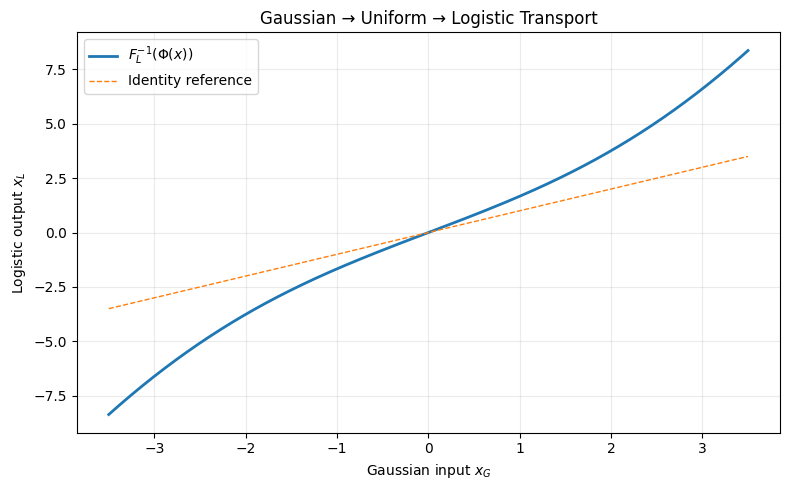

In [630]:
x_gaussian_grid = np.linspace(-3.5, 3.5, 400)

uniform_values = norm.cdf(x_gaussian_grid)

x_logistic_grid = logistic.ppf(uniform_values)

plt.figure(figsize=(8, 5))

plt.plot(
    x_gaussian_grid,
    x_logistic_grid,
    linewidth=2,
    label=r"$F_L^{-1}(\Phi(x))$",
)

# Identity line for reference
plt.plot(
    x_gaussian_grid,
    x_gaussian_grid,
    linestyle="--",
    linewidth=1,
    label="Identity reference",
)

plt.xlabel("Gaussian input $x_G$")
plt.ylabel("Logistic output $x_L$")
plt.title("Gaussian → Uniform → Logistic Transport")

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

The transformation is monotone because both the Gaussian CDF $\Phi$ and the Logistic inverse CDF $F_L^{-1}$ are monotone.

The intermediate uniform value is

$$
u=\Phi(x_G),
$$

and the final output is

$$
x_L=F_L^{-1}(u).
$$

Therefore the complete transport is

$$
T(x_G)=F_L^{-1}(\Phi(x_G)).
$$

This clarifies the ordering: the Uniform distribution is not an arbitrary extra step. It is the intermediate probability scale that connects the Gaussian CDF to the Logistic inverse CDF.

## What this reveals about the current `TrueMeasure` abstraction

The domain-inclusion change answers one question:

> When two existing transformations are composed, is the output range of the first valid input for the second?

However, Gaussian-to-Logistic transport introduces a second question.

The current `TrueMeasure._transform` interface is primarily designed around transformations that generate a measure from the input supplied by the preceding sampler. For common inverse-CDF constructions, the map is naturally

$$
(0,1) \rightarrow \text{target support}.
$$

A Gaussian-to-Logistic transport instead requires the forward Gaussian CDF

$$
\Phi:\mathbb{R}\rightarrow(0,1)
$$

followed by the Logistic inverse CDF

$$
F_L^{-1}:(0,1)\rightarrow\mathbb{R}.
$$

Therefore, domain-range inclusion alone does not automatically create this transport.

The inclusion change makes existing compatible transformation chains more general, while explicit distribution-to-distribution transport may require additional transformation semantics.

## Transport versus importance sampling

A Logistic distribution may also be used as an importance-sampling proposal for a Gaussian target.

That is a different operation from transporting Gaussian samples into Logistic samples.

If

$$
p(x)
$$

is the Gaussian target density and

$$
q(x)
$$

is the Logistic proposal density, then samples are generated from

$$
X \sim q
$$

and weighted using

$$
w(X)=\frac{p(X)}{q(X)}.
$$

The corresponding integrand becomes

$$
g(X)\frac{p(X)}{q(X)}.
$$

In this case, Logistic is a proposal distribution rather than an intermediate deterministic transport.

These two concepts should remain separate:

1. **Transformation composition:** can the output space of one deterministic transformation feed the next?
2. **Importance sampling:** can another measure be used to generate samples and corrected using density ratios?

# Conclusions

This investigation establishes the following:

1. The previous chained `TrueMeasure` compatibility rule effectively required exact equality between the range of one transformation and the domain of the next:

   $$
   R_{j-1} = D_j.
   $$

2. Exact equality is unnecessarily restrictive for domain compatibility. For the current interval and axis-aligned box representation, compatibility can instead be generalized to coordinate-wise range-in-domain containment:

   $$
   R_{j-1} \subseteq D_j.
   $$

   Equality remains valid because it is a special case of containment.

3. In one dimension, for

   $$
   R_{j-1} = [r_L,r_U]
   $$

   and

   $$
   D_j = [d_L,d_U],
   $$

   compatibility requires

   $$
   d_L \leq r_L
   \qquad\text{and}\qquad
   r_U \leq d_U.
   $$

   The same rule extends coordinate-wise to multidimensional axis-aligned boxes. QMCPy's `(1,2)` and `(d,2)` representations remain interoperable through NumPy broadcasting.

4. The behavior change can be seen directly in the motivating example:

   Previous behavior required

   $$
   [0.25,0.75] = [0,1],
   $$

   which is false, so the chain was considered incompatible.

   Under the updated rule,

   $$
   [0.25,0.75] \subseteq [0,1],
   $$

   so the chain is correctly accepted as domain-compatible because every output of the preceding transformation lies inside the input domain of the next transformation.

5. The change does not weaken compatibility checking. A range that actually extends outside the next domain is still rejected. For example,

   $$
   [-0.1,0.75] \nsubseteq [0,1].
   $$

6. The initial scope is one-dimensional intervals and multidimensional axis-aligned boxes with finite or unbounded numerical endpoints, represented using values such as `-np.inf` and `np.inf`. Because the metadata does not separately encode open and closed finite endpoints, the comparison operates on stored interval envelopes. Disconnected supports such as

    $$
    [0,5]\cup[10,20]
    $$

    and arbitrary nonrectangular domains are outside the scope of this change.

7. Exploring Gaussian, Uniform, and Logistic transformations clarifies an additional point. A Gaussian-to-Logistic deterministic transport is naturally

    $$
    X_G
    \xrightarrow{\Phi}
    U
    \xrightarrow{F_L^{-1}}
    X_L,
    $$

    or conceptually,

    $$
    \mathrm{Gaussian}
    \rightarrow
    \mathrm{Uniform}
    \rightarrow
    \mathrm{Logistic}.
    $$

    The complete transport can be written as

    $$
    T(x)=F_L^{-1}(\Phi(x)).
    $$

8. The reverse transport is

    $$
    X_L
    \xrightarrow{F_L}
    U
    \xrightarrow{\Phi^{-1}}
    X_G.
    $$

    The numerical round-trip experiment recovers the original Gaussian values up to floating-point roundoff, confirming the expected inverse relationship.

9. This also shows an important limitation of the current change: domain-range inclusion makes existing transformation chains more flexible, but it does not by itself create arbitrary distribution-to-distribution transport maps.

    A Gaussian-to-Logistic transport requires a forward Gaussian CDF followed by a Logistic inverse CDF, while many current `TrueMeasure` transformations are structured primarily around generating a target measure from the preceding sampler.

10. Transport and importance sampling should therefore remain conceptually separate.

    For transport, the concern is whether deterministic maps can be composed through compatible intermediate spaces.

    For importance sampling, a proposal density $q$ can instead be used to sample $X$ and correct for a target density $p$ using

    $$
    g(X)\frac{p(X)}{q(X)}.
    $$

    The Logistic distribution can therefore play a different role as an importance-sampling proposal rather than as an intermediate deterministic transport.

Hence, this change provides a small but useful generalization of `TrueMeasure` composition:

$$
\boxed{
R_{j-1} = D_j
\quad\longrightarrow\quad
R_{j-1} \subseteq D_j
}
$$

for the current interval and axis-aligned box representation.

It recognizes domain-compatible chained transformations that were previously rejected solely because their intermediate bounds were not identical, while preserving rejection of genuinely incompatible boundaries.